# Tutorial 8: Operations with saved data

Data stored in a NeXus file can be accessed using `mlgidBASE.nexus` functions. Internally, this relies on the `pygid.NexusFile` class, which is built on top of the `h5py` package. The details are described in [`pygid` documentation](https://pygid.readthedocs.io/en/latest/tutorials/tutorial_11_saved_data.html).

First, create an `mlgidBASE` instance and run the analysis:

In [1]:
from mlgidbase import mlgidBASE
filename = '../../example/BA2PbI4.h5'
analysis = mlgidBASE(filename=filename)
analysis.run_detection()
analysis.run_fitting()

analysis.run_matching(
    cif_prepr = r'../../example/prepr_cifs.pickle',
    peaks_type='segments')

analysis.run_matching(
    cif_prepr = r'../../example/prepr_cifs.pickle',
    peaks_type='rings')

INFO - Loading model
INFO - Using the GPU for inference
INFO - Saved detected peaks to file: ../../example/BA2PbI4.h5, entry: entry_0000, frame: 0
INFO - Saved fitted peaks to file: ../../example/BA2PbI4.h5, entry: entry_0000, frame: 0
INFO - Saved matched peaks to file: ../../example/BA2PbI4.h5, entry: entry_0000, frame: 0
INFO - cif_prepr is already set. The previous cif_prepr is to be used
INFO - Saved matched peaks to file: ../../example/BA2PbI4.h5, entry: entry_0000, frame: 0


Print the file structure:

In [2]:
analysis.nexus.print_file_structure()

File structure: ../../example/BA2PbI4.h5
{'entry_0000': {'axes': ['q_z', 'q_xy'],
                'description': 'cylindrical coordinate conversion for GID '
                               'geometry',
                'img_type': 'img_gid_q',
                'shape': (1, 1750, 1750)}}


### Read the detected peaks

In [3]:
detected_peaks = analysis.get_detected_peaks()
detected_peaks['entry_0000']['0']

array([(0., 32.427277 ,  3.4301147, 1.6976575 , 0.04610777, 0.91033256, 1.4329464 , 0., 0.9999976 , 0., 0., 0., False, False, False, 0,  0),
       (0., 51.998474 ,  3.123932 , 2.320836  , 0.05733991, 1.8288057 , 1.4288981 , 0., 0.9999883 , 0., 0., 0., False, False, False, 0,  1),
       (0., 63.724487 ,  4.3052063, 2.283905  , 0.05747008, 2.0479221 , 1.0110574 , 0., 0.99998546, 0., 0., 0., False, False, False, 0,  2),
       (0., 23.122437 ,  2.6454163, 1.7503606 , 0.03783154, 0.68736184, 1.6097503 , 0., 0.99997425, 0., 0., 0., False, False, False, 0,  3),
       (0., 42.255432 ,  3.710205 , 3.041603  , 0.06829095, 2.0452864 , 2.2512558 , 0., 0.99996734, 0., 0., 0., False, False, False, 0,  4),
       (0., 15.88324  ,  2.5837097, 1.658978  , 0.03913963, 0.4540256 , 1.5956405 , 0., 0.9999442 , 0., 0., 0., False, False, False, 0,  5),
       (0., 34.0896   ,  2.8281555, 1.2281849 , 0.02517474, 0.68838376, 1.0171362 , 0., 0.9999411 , 0., 0., 0., False, False, False, 0,  6),
       (0., 3

It returns a multilayered dictionary structure:

- **entry** — top-level key corresponding to each entry in the file
  - **frame number** — sub-key corresponding to each frame in the entry

You can access detected boxes information such as box centers as follows:

In [4]:
q_xy, q_z = detected_peaks['entry_0000']['0']['q_xy'], detected_peaks['entry_0000']['0']['q_z']
q_xy.shape, q_z.shape

((95,), (95,))

### Read the fitted peaks

In [5]:
fitted_peaks = analysis.get_fitted_peaks()
fitted_peaks['entry_0000']['0']

array([(6.7566010e+02, 32.421303 , 1.1329187 , 1.6984148 , 0.04147886, 0.9105893 , 1.4336805 ,  0., 0.9999976 ,  -20.687923 ,  1.4725417 ,   198.63441  , False, False, False, 0,  0),
       (2.4723970e+02, 51.753757 , 1.243038  , 2.3124957 , 0.06077257, 1.8161359 , 1.4315331 ,  0., 0.9999883 ,  -20.687923 ,  0.00634714,   221.2811   , False, False, False, 0,  1),
       (1.2808958e+03, 63.59366  , 1.1973839 , 2.281721  , 0.05442685, 2.043652  , 1.0147598 ,  0., 0.99998546,  -20.687923 ,  1.406057  ,   145.74939  , False, False, False, 0,  2),
       (3.1531558e+02, 23.001713 , 0.98988295, 1.7499484 , 0.03589573, 0.6838075 , 1.6108155 ,  0., 0.99997425,  -20.687923 ,  2.8553255 ,   167.88124  , False, False, False, 0,  3),
       (5.2162653e+02, 42.091644 , 1.1197909 , 3.0453718 , 0.07276262, 2.0413687 , 2.25989   ,  0., 0.99996734,   20.687923 , -2.5318625 ,   170.08418  , False, False, False, 0,  4),
       (3.8954254e+02, 15.958809 , 1.0163413 , 1.655431  , 0.03999717, 0.45515448, 1.

It returns a multilayered dictionary structure:

- **entry** — top-level key corresponding to each entry in the file
  - **frame number** — sub-key corresponding to each frame in the entry

You can access fitted peak information such as peak centers, types, and amplitudes as follows:

In [6]:
q_xy = fitted_peaks['entry_0000']['0']['q_xy']
q_z = fitted_peaks['entry_0000']['0']['q_z']
amp = fitted_peaks['entry_0000']['0']['amplitude']
is_ring = fitted_peaks['entry_0000']['0']['is_ring']

q_xy.shape, q_z.shape, amp.shape, is_ring.shape

((95,), (95,), (95,), (95,))

Get only segments

In [7]:
q_xy_peaks = q_xy[~is_ring]
q_z_peaks = q_z[~is_ring]
amp_peaks = amp[~is_ring]

q_xy_peaks.shape, q_z_peaks.shape, amp_peaks.shape,

((79,), (79,), (79,))

Get only rings

In [8]:
q_xy_rings = q_xy[is_ring]
q_z_rings = q_z[is_ring]
amp_rings = amp[is_ring]

q_xy_rings.shape, q_z_rings.shape, amp_rings.shape,

((16,), (16,), (16,))

### Read the matched solutions

In [9]:
matched_peaks = analysis.get_matched_peaks()
matched_peaks['entry_0000']['0']['matched_rings_0000']

array([(b'In2O3_14387.cif', 0, 0, 0, 0.99880445, array([13, 17, 26, 27, 35, 37, 43, 49, 51, 60, 64, 75, 88], dtype=int32))],
      dtype={'names': ['CIF', 'h', 'k', 'l', 'probability', 'peak_list'], 'formats': ['S64', '<i4', '<i4', '<i4', '<f4', 'O'], 'offsets': [0, 64, 68, 72, 76, 80], 'itemsize': 96})

The analysis returns a multilayered dictionary structure:

- **entry** — top-level key corresponding to each entry in the file
  - **frame number** — sub-key corresponding to each frame in the entry
    - **solution** — sub-key corresponding to each solution for this frame

Each solution contains detected or matched peak information, such as peak centers, types, amplitudes, and matched CIF identifiers. For example, to access a specific matched peak set:


In [10]:
CIF_list = matched_peaks['entry_0000']['0']['matched_rings_0000']['CIF']
probability_list = matched_peaks['entry_0000']['0']['matched_rings_0000']['probability']
peak_list = matched_peaks['entry_0000']['0']['matched_rings_0000']['peak_list']

num = 0 # structure number in the given solution
CIF_list[num].decode('utf-8'), peak_list[num]

('In2O3_14387.cif',
 array([13, 17, 26, 27, 35, 37, 43, 49, 51, 60, 64, 75, 88], dtype=int32))

You can recursively print a multilayered dictionary:

In [13]:
import numpy as np
for entry, frames in matched_peaks.items():
    print(f"\nEntry: {entry}")
    print("="*60)
    for frame_num, solutions in frames.items():
        print(f"  Frame: {frame_num}")
        print("  " + "-"*56)
        for solution, data in solutions.items():
            # Iterate over lists of CIFs and probabilities
            for cif, prob in zip(data['CIF'], data['probability']):
                # Decode bytes to string
                cif_name = cif.decode('utf-8')
                print(f"    Solution: {solution:<15} CIF: {cif_name:<25} Probability: {prob}")
        print("  " + "-"*56)


Entry: entry_0000
  Frame: 0
  --------------------------------------------------------
    Solution: matched_rings_0000 CIF: In2O3_14387.cif           Probability: 0.9988044500350952
    Solution: matched_segments_0000 CIF: 1_BA2PbI4_n1.cif          Probability: 0.9957428574562073
  --------------------------------------------------------


### Get a pygid.Conversion instance

Additionally, the `pygid.Conversion` can be loaded for simulations:

In [18]:
conversion = analysis.nexus.load_entry(
    entry = 'entry_0000',  # entry name to load
    frame_num = 0,         # frame number to load (int, list or None (all))
)

INFO - Simulating GIWAXS data from CIF: ../../example/cifs/1_BA2PbI4_n1.cif, orientation: [0, 0, 1]
INFO - Use already converted image with frame num 0


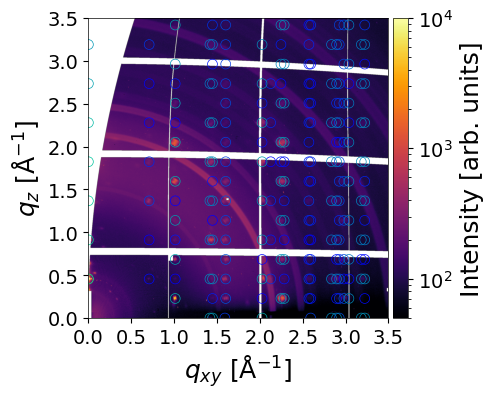

In [25]:
crystal = {
    'path_to_cif': '../../example/cifs/1_BA2PbI4_n1.cif', # path to CIF
    'orientation': [0,0,1],                               # contact plane
    'min_int': 1e-5,                                      # minimal peak intensity to simulate
}

conversion.make_simulation(
    frame_num=0,                  # Frame of experimental data
    crystal=crystal,
    plot_result=True,             # Display simulation overlay
    clims=(50, 1e4),              # Intensity limits
)